## Regresion Lineal Simple

La regresion lineal es un algoritmo utilizado en modelos de entrenamiento supervisado y se utiliza para predecir o estimar una variable dependiente "y" en funcion a otra variable o conjunto de variables independientes "X".

La variable "y" es la que deseamos **Predecir** o **Estimar**, en cambio la variable "X" es la que se utilizara para **Entrenar** el modelo.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

Se desea predecir la nota de un alumno en funcion a la cantidad de horas a la semana que estudio para un examen.

Para ello se tomo una muestra de 12 alumnos.

In [12]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
datos = {
    "Horas de Estudio(x)" : pd.Series ([3,6,8,2,1,6,3,6,8,2,1,6], ["Alex", "Pedro", "Maria", "Jose", "Juan", "Chris", "Mario", "Lorenzo", "Stephanie", "Tiffany", "Rafael", "Carlos"]),
    "Notas (Y)" : pd.Series({"Alex":8,"Pedro":10, "Maria":15, "Jose":8, "Juan":5, "Chris": 12, "Mario":8, "Lorenzo":10, "Stephanie":15, "Tiffany":8, "Rafael":5, "Carlos":12})
}
df = pd.DataFrame(datos)
df
                            

,Horas de Estudio(x),Notas (Y)
Alex,3,8
Pedro,6,10
Maria,8,15
Jose,2,8
Juan,1,5
Chris,6,12
Mario,3,8
Lorenzo,6,10
Stephanie,8,15
Tiffany,2,8


In [13]:
print("Visualizacion Preliminar del Dataset")
print("Forma del Dataset:", df.shape)
print("Columnas del Dataset:")
print(list(df.columns))
print("\nTipo de datos:")
print(df.dtypes)


Visualizacion Preliminar del Dataset
Forma del Dataset: (12, 2)
Columnas del Dataset:
['Horas de Estudio(x)', 'Notas (Y)']

Tipo de datos:
Horas de Estudio(x)    int64
Notas (Y)              int64
dtype: object


In [55]:
total_nota_promedio = df['Notas (Y)'].median()

##Modelo regresion lineal simple

X_simple = df[['Horas de Estudio(x)']]
y = df['Notas (Y)']

modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)

#identificando el coeficiente del modelo con el objetivo de saber si el modelo esta aprendiendo o no.
print('Pendiente:', round(modelo_simple.coef_[0], 2))
print('Intercepto:', round(modelo_simple.intercept_, 2))

ingreso_nuevo = pd.DataFrame([[total_nota_promedio]], columns=['Horas de Estudio(x)'])
prediccion = modelo_simple.predict(ingreso_nuevo)
error_maximo = max_error(ingreso_nuevo, prediccion)

print()
print(f'Para una Cantidad Promedio de {total_nota_promedio} horas de estudio, el modelo predice: la nota total {prediccion[0]:,.2f}')
print("Error Absoluto Maximo: ", round(error_maximo,2))


Pendiente: 1.22
Intercepto: 4.37

Para una Cantidad Promedio de 9.0 horas de estudio, el modelo predice: la nota total 15.37
Error Absoluto Maximo:  6.37


## Visualizacion de la regresion lineal.

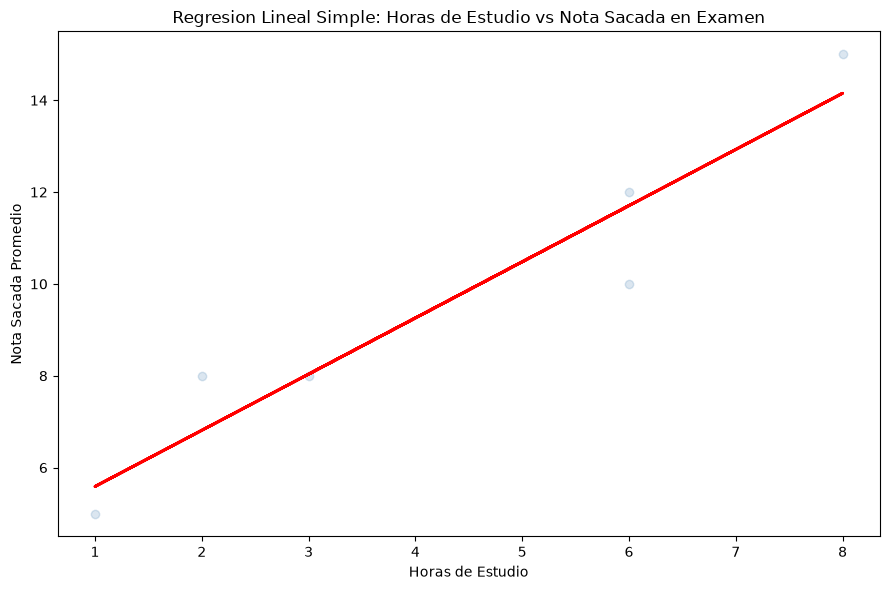

In [25]:
plt.figure(figsize=(9,6))
plt.scatter(df['Horas de Estudio(x)'], df['Notas (Y)'], alpha=0.1, color='steelblue')
plt.plot(df['Horas de Estudio(x)'], modelo_simple.predict(X_simple), color='red', linewidth=2)
plt.title("Regresion Lineal Simple: Horas de Estudio vs Nota Sacada en Examen")
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota Sacada Promedio")
plt.tight_layout()

plt.show()

## Hallazgos: 

Se puede observar que existe una relacion directa entre las horas de estudios y la nota obtenida en el examen, en donde a mayor horas de estudios el estudiante obtuvo mayor puntaje. 

Por cada hora adicional de estudio la nota aumenta 1.22 puntos

## Metricas para Regresion

Residuo/Error: es la diferencia entre el valor real y el valor que el modelo predice.

**Error Absoluto Maximo (M)** 

Calcula la diferencia maxima entre el valor predicho y el valor real. Esta metrica nos ayuda a controlar el error maximo que predice el modelo.

In [40]:


y_verdadero = [1,2,3,4,5]
y_predicho = [1,2,3,4,-5]
max_error(y_verdadero, y_predicho)




10.0

**Error Absoluto Medio (Mean Absolute error (MAE)**

Esta metrica responde a la pregunta, cuanto se equivoca mi modelo en promedio?. Como se trata de un valor absoluto este va a ignorar la naturaleza del numero ya sea positivo o negativo. Se usa cuando se quiere una medida sencilla y facil de comunicar e incluso esta en dolares asi que se puede usar en predicciones que sean en dolares.

In [41]:
y_verdadero = [1,2,3,4,5]
y_predicho = [1,2,3,4,-5]
mean_absolute_error(y_verdadero, y_predicho)

2.0

**Error Cuadratico Medio (MSE)**

Esta metrica al igual que **MAE** intenta calcular el residuo pero no de manera absoluta sino que lo hace elevando los numeros al cuadrado eliminando consigo los valores negativos. Esta metrica le da mucho peso a los errores grandes ya que al elevarlo al cuadrado el numero incrementa bastante. Se utiliza cuando los errores grandes son especialmente graves. 

Ejemplo de uso:
+ Medicina
+ Aviacion
+ Finanzas

In [42]:
y_verdadero = [1,2,3,4,5]
y_predicho = [1,2,3,4,-5]
mean_squared_error(y_verdadero, y_predicho)

20.0

**Raiz Cuadrada del error Cuadratico Medio (RMSE)**

Debido a lo estricto que es **MSE** y al trabajar en dolares es mas dificil de interpretar. Por esta razon, se utiliza RMSE ya que saca la raiz cuadrada de **MSE** y volveremos a tener los valores en dolares y no en dolares al cuadrado.

In [50]:
y_verdadero = [1,2,3,4,5]
y_predicho = [1,2,3,4,-5]
mse  = mean_squared_error(y_verdadero, y_predicho)
rsme = mse ** 0.5
rsme

4.47213595499958

**Coeficiente de Determinacion**

Esta metrica solo aplica para modelos de regresion lineal. 

No mide el error, pero responde a la pregunta de que porcentaje del comportamiento de los datos logra explicar el modelo? y los valores van desde el 0 hasta el 1. Un modelo perfecto tendria como resultado 1.00. 

Esta metrica debe ser utilizada siempre, es la mas utilizada para responder a que tan bien se ajusta la recta a los datos. 

In [51]:
y_verdadero = [1,2,3,4,5]
y_predicho = [1,2,3,4,-5]
r2_score(y_verdadero, y_predicho)

-9.0

## En Resumen 

MAE mide el error promedio absoluto y es ideal mientras mas cercano a 0
MSE mide el error promedio al cuadrado y es ideal mas cercano a 0
RMSE midel el error promedio (castigando errores grandes) y es ideal mas cercano a 0
R2 o coeficiente de determinacion mide que tanto explica el modelo y es ideal mas cercano a 1

#### Cual usan mas los cientificos de datos?

MAE: Facil de explicar al cliente o al negocio
RMSE: Muy usada para evaluar modelos porque penaliza mas los errores grandes.
R2: Indica que tan bien explica el modelo la variabilidad de los datos.


### Una regla sencilla para recordar

Cuando empieces un proyecto de regresión, puedes pensar así:

* MAE → ¿En promedio cuánto me equivoco? (la métrica más fácil de explicar al negocio).
* MSE → ¿Quiero castigar mucho los errores grandes durante el entrenamiento o la optimización?
* RMSE → ¿Cuál es el error típico, pero dando más peso a los errores grandes? (muy común para comparar modelos).
* R² → ¿Qué tan bien explica el modelo el comportamiento de los datos?
* Max Error → ¿Cuál fue la peor predicción? (ideal para detectar casos extremos que pueden ser críticos).

En la práctica, es muy común que un Data Scientist reporte **MAE**, **RMSE** y **R²** juntos. Esa combinación le permite responder tres preguntas clave: cuánto se equivoca el modelo en promedio, si existen errores grandes que preocupen y qué tan bien explica el fenómeno que intenta predecir.

## Que usan las empresas grandes

| Empresa | Problema de negocio | Métrica más utilizada | ¿Por qué? |
|----------|---------------------|------------------------|-----------|
| **Zillow** | Predicción del precio de viviendas | **MAE + RMSE + R²** | MAE comunica el error promedio en dólares, RMSE penaliza grandes errores y R² indica qué tan bien explica el modelo el comportamiento de los precios. |
| **Uber** | Predicción del tiempo de viaje | **RMSE** | Los errores grandes afectan significativamente la experiencia del usuario, por lo que se penalizan más. |
| **Amazon** | Predicción de ventas | **MAE** | Es una métrica fácil de interpretar para el negocio y expresa el error promedio en unidades vendidas o ingresos. |
| **Tesla** | Predicción de la autonomía de la batería | **RMSE + Max Error** | Además del error promedio, es importante conocer el peor error posible por razones de seguridad y confianza del usuario. |
| **Bancos** | Predicción de riesgo financiero o montos de préstamos | **MSE + RMSE** | Un error muy grande puede representar pérdidas económicas importantes, por lo que se castigan más los errores extremos. |
| **Hospitales** | Predicción de días de hospitalización | **MAE + Max Error** | Se busca conocer el error promedio y también identificar casos donde la predicción falle considerablemente. |
| **Netflix** | Predicción de la calificación de películas | **RMSE + R²** | RMSE mide la precisión de las recomendaciones y R² indica qué tan bien el modelo explica las preferencias de los usuarios. |